<a href="https://colab.research.google.com/github/nasif-raihan/GSU/blob/main/CSCI_7090_Module3_Lab1_Preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Module 3 — Data Preprocessing (Lab)
**Computer Vision · Machine Learning for Vision**

Runs anywhere: uses scikit-learn's built-in **breast-cancer** dataset (a labelled, all-numeric medical dataset). To use your own data instead, replace the load cell with `df = pd.read_csv("your.csv")` and set `TARGET`.

## 1. Load the dataset

In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import MinMaxScaler, StandardScaler

data = load_breast_cancer(as_frame=True)
df = data.frame                     # 30 features + a 'target' column
TARGET = "target"                   # 0 = malignant, 1 = benign
print("shape:", df.shape)
df.head()

shape: (569, 31)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


## 2. Structure & missing values

In [2]:
df.info()
print("\nMissing values per column:\n", df.isnull().sum().to_string())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

## 3. Statistical summary & outliers (boxplots)

In [3]:
df.describe()


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


                           mean         std        min        max
mean radius           14.127292    3.524049    6.98100    28.1100
mean texture          19.289649    4.301036    9.71000    39.2800
mean perimeter        91.969033   24.298981   43.79000   188.5000
mean area            654.889104  351.914129  143.50000  2501.0000
mean smoothness        0.096360    0.014064    0.05263     0.1634
mean compactness       0.104341    0.052813    0.01938     0.3454
mean concavity         0.088799    0.079720    0.00000     0.4268
mean concave points    0.048919    0.038803    0.00000     0.2012


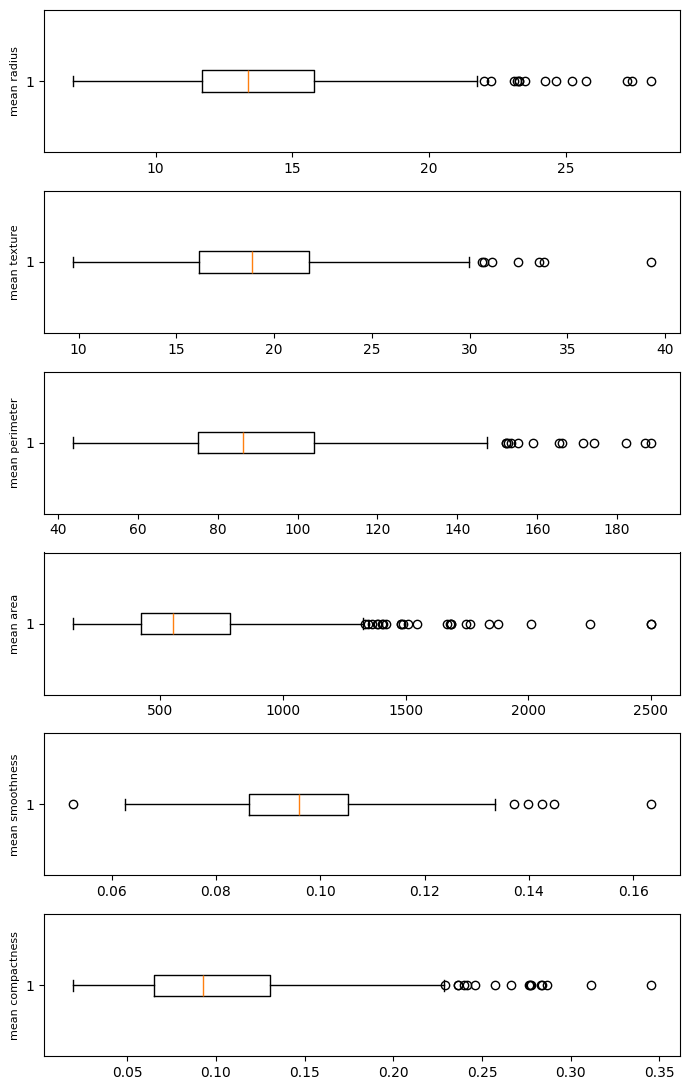

In [4]:
print(df.describe().T[["mean","std","min","max"]].head(8))
cols = list(df.columns[:6])
fig, axs = plt.subplots(len(cols), 1, figsize=(7, 11))
for i, col in enumerate(cols):
    axs[i].boxplot(df[col], vert=False); axs[i].set_ylabel(col, fontsize=8)
plt.tight_layout(); plt.show()

## 4. Remove outliers with the IQR rule
Values below `Q1 − 1.5·IQR` or above `Q3 + 1.5·IQR` are outliers. We apply it to a few representative columns and **keep the cleaned data** for later steps.

In [5]:
clean_df = df.copy()
for col in ["mean area", "mean compactness", "worst area"]:
    q1, q3 = np.percentile(clean_df[col], [25, 75]); iqr = q3 - q1
    lo, hi = q1 - 1.5*iqr, q3 + 1.5*iqr
    clean_df = clean_df[(clean_df[col] >= lo) & (clean_df[col] <= hi)]
print(f"rows before: {len(df)}  ->  after outlier removal: {len(clean_df)}")
df = clean_df       # propagate the cleaned data downstream

rows before: 569  ->  after outlier removal: 488


## 5. Correlation analysis

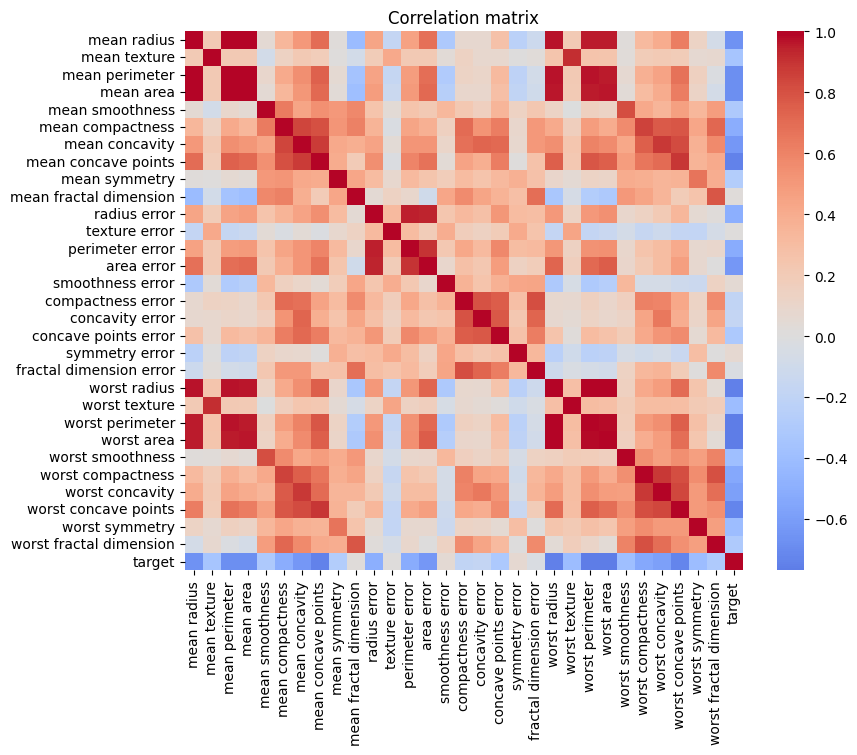

Most correlated with target:
 target                     1.000000
symmetry error             0.060542
smoothness error           0.048930
mean fractal dimension     0.019397
texture error              0.018340
fractal dimension error   -0.025447


In [6]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(9, 7))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation matrix"); plt.show()
print("Most correlated with target:\n", corr[TARGET].sort_values(ascending=False).head(6).to_string())

## 6. Target class balance
Check whether the classes are balanced. Note the label order matches `sort_index()` (0 then 1).

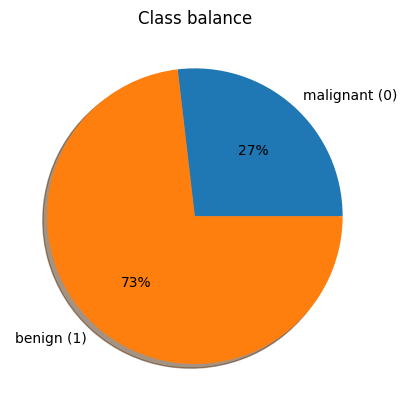

target
0    131
1    357


In [7]:
counts = df[TARGET].value_counts().sort_index()
plt.pie(counts, labels=["malignant (0)", "benign (1)"], autopct="%.0f%%", shadow=True)
plt.title("Class balance"); plt.show()
print(counts.to_string())

## 7. Separate features and target

In [8]:
X = df.drop(columns=[TARGET])
y = df[TARGET]
print("X:", X.shape, "| y:", y.shape)

X: (488, 30) | y: (488,)


## 8. Feature scaling
**Normalization** (Min-Max) rescales to [0, 1] — good for k-NN. **Standardization** gives mean 0, std 1.

In [9]:
X_norm = MinMaxScaler().fit_transform(X)
print("Min-Max scaled (first 2 rows, first 5 cols):\n", np.round(X_norm[:2, :5], 3))

Min-Max scaled (first 2 rows, first 5 cols):
 [[1.    0.157 1.    1.    0.43 ]
 [0.411 0.203 0.425 0.289 0.679]]


In [10]:
X_std = StandardScaler().fit_transform(X)
print("Standardized (first 2 rows, first 5 cols):\n", np.round(X_std[:2, :5], 3))

Standardized (first 2 rows, first 5 cols):
 [[ 2.868 -1.063  2.95   3.459  0.382]
 [-0.278 -0.738 -0.148 -0.346  2.378]]
